# Bayesiaanse afspeellijstaanbeveling — ML model

Dit notebook traint een hiërarchisch Bayesiaans model dat per deelnemer de beste
afspeellijst (Calm / Neutral / Energy) voorspelt op basis van stemming en biometrie.

**Pipeline:** data laden → model bouwen → samplen → diagnostiek → artefacten exporteren.
Visualisaties en deelnemersinzichten staan in `visualisation/bayesian_recommender_viz.ipynb`.

**Vereisten** — voer eerst uit:
```bash
uv run python scripts/baseline/pipeline.py --all
uv run python scripts/sessions/pipeline.py --all
```

Zet `REUSE_MODEL = False` om opnieuw te samplen (∼30 s via JAX/NumPyro).

In [1]:
REUSE_MODEL   = True
DRAWS         = 1000
TUNE          = 500
CHAINS        = 4
TARGET_ACCEPT = 0.9

---

## 1. Setup

In [2]:
import json
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

PROJECT_ROOT = Path().resolve().parent.parent
DATA_ROOT    = PROJECT_ROOT / "data"
MODELS_DIR   = PROJECT_ROOT / "models" / "bayesian_recommender"
BAYES_OUT    = DATA_ROOT / "analysis" / "bayesian_recommender"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
BAYES_OUT.mkdir(parents=True, exist_ok=True)

PLAYLIST_MAP   = {"Calm": 0, "Neutral": 1, "Energy": 2}
PLAYLIST_NAMES = ["Calm", "Neutral", "Energy"]

plt.rcParams.update({
    "figure.facecolor": "#0f1218", "axes.facecolor": "#181e2a",
    "axes.edgecolor":   "#232b3a", "axes.labelcolor": "#c9d1d9",
    "axes.grid": True,  "grid.color": "#232b3a", "grid.linewidth": 0.5,
    "text.color":       "#c9d1d9", "xtick.color": "#586475", "ytick.color": "#586475",
    "legend.facecolor": "#181e2a", "legend.edgecolor": "#232b3a",
    "font.family":      "monospace", "font.size": 9, "figure.dpi": 120,
})

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


---

## 2. Hulpfuncties

In [3]:
VALENCE_MAP = {
    "gestresseerd of gespannen": -1, "moe of ongemotiveerd": -1, "moe en gespannen...": -1,
    "neutraal": 0, "neutraal tot een goed gevoel": 0,
    "rustig": 1, "gemotiveerd": 1, "happy": 1, "happy - gemotiveerd": 1, "goed gevoel": 1,
}

def emotion_valence(emotion: str) -> int:
    """Map an emotion string to its valence (-1, 0, +1)."""
    key = emotion.strip().lower()
    if key in VALENCE_MAP:
        return VALENCE_MAP[key]
    if any(w in key for w in ("stress", "gespannen", "moe", "ongemot")):
        return -1
    if any(w in key for w in ("happy", "goed", "gemotiv", "rustig", "blij")):
        return 1
    return 0

def composite_mood(emotion: str, intensity: float) -> float:
    """Compute valence-weighted mood score: valence * intensity."""
    return emotion_valence(emotion) * intensity

In [4]:
def load_biometric_sessions(codename: str) -> pd.DataFrame:
    """Load session_biometrics.csv for a participant with wearable data."""
    path = DATA_ROOT / "wearables" / codename / "processed" / "session_biometrics.csv"
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["participant"] = codename
    df["has_biometrics"] = True
    return df


def load_checkin_sessions() -> pd.DataFrame:
    """Load check-in CSV and compute mood scores for all participants."""
    for checkin_path in [
        DATA_ROOT / "check_in" / "check_in.csv",
        DATA_ROOT / "checkins" / "Check-in_formulier_REM.csv",
    ]:
        if checkin_path.exists():
            break
    else:
        raise FileNotFoundError("No check-in CSV found")

    ci = pd.read_csv(checkin_path)
    rows = []
    for _, r in ci.iterrows():
        emotion_before = str(r["Welk gevoel had je?"])
        emotion_after  = str(r["Welk gevoel had je?.1"])
        intensity_before = float(r["Score van de intensiteit van je gevoel"])
        intensity_after  = float(r["Score van de intensiteit van je gevoel.1"])
        playlist_raw = str(r["Welke playlist luisterde je?"])
        playlist = playlist_raw.strip().capitalize()
        if playlist not in PLAYLIST_MAP:
            continue
        start_str = str(r.get("Starttijd?", ""))
        try:
            hour = pd.to_datetime(start_str, format="%H:%M:%S").hour
        except Exception:
            try:
                hour = int(start_str.split(":")[0])
            except Exception:
                hour = 12
        rows.append({
            "participant":          str(r["Deelnemerscode"]).strip().lower(),
            "playlist":             playlist,
            "emotion_before":       emotion_before,
            "emotion_after":        emotion_after,
            "intensity_before":     intensity_before,
            "intensity_after":      intensity_after,
            "mood_before_composite": composite_mood(emotion_before, intensity_before),
            "mood_after_composite":  composite_mood(emotion_after, intensity_after),
            "hour_of_day":          hour,
        })
    df = pd.DataFrame(rows)
    df["mood_delta"] = df["mood_after_composite"] - df["mood_before_composite"]
    return df


def _load_feature_matrix() -> pd.DataFrame | None:
    """Load circadian feature matrix if available (provides baseline deviations)."""
    fm_path = DATA_ROOT / "analysis" / "circadian_baselines" / "feature_matrix.csv"
    if not fm_path.exists():
        return None
    fm = pd.read_csv(fm_path)
    fm["date"] = pd.to_datetime(fm["date"]).dt.date
    return fm


def build_model_data(participants_with_bio):
    """Combine biometric sessions and check-in-only sessions into one DataFrame.

    Participants with biometrics get full feature vectors.
    Check-in-only participants contribute mood + playlist data (biometrics = NaN).
    Returns (combined_df, participant_codes).
    """
    checkin_df = load_checkin_sessions()
    fm = _load_feature_matrix()
    use_circadian = fm is not None
    if use_circadian:
        print("  Circadiane basisafwijkingen worden gebruikt (feature_matrix.csv).")
    else:
        print("  WAARSCHUWING: feature_matrix.csv niet gevonden \u2014 ruwe stress/HR wordt gebruikt.")
        print("  Voer scripts/baseline/pipeline.py uit voor circadiane correctie.")

    bio_frames = []
    bio_participants = set()

    if participants_with_bio:
        for code in participants_with_bio:
            bio = load_biometric_sessions(code)
            if bio.empty:
                continue
            bio_participants.add(code)
            if use_circadian:
                bio["_date"] = pd.to_datetime(bio["date"], errors="coerce").dt.date
                fm_part = fm[fm["participant"] == code].copy()
            bio_rows = []
            for _, r in bio.iterrows():
                ci_match = checkin_df[
                    (checkin_df["participant"] == code)
                    & (checkin_df["playlist"] == r["playlist"])
                ]
                if not ci_match.empty:
                    ci_row = ci_match.iloc[0]
                    mood_before_comp = ci_row["mood_before_composite"]
                    mood_after_comp  = ci_row["mood_after_composite"]
                    mood_delta       = ci_row["mood_delta"]
                else:
                    mood_before_comp = 0.0
                    mood_after_comp  = 0.0
                    mood_delta = float(r["mood_after_score"]) - float(r["mood_before_score"])
                stress_val = r.get("pre_stress_mean")
                hr_val     = r.get("pre_hr_mean")
                if use_circadian:
                    row_date = r.get("_date") if "_date" in r.index else None
                    if row_date is not None:
                        fm_match = fm_part[fm_part["date"] == row_date]
                        if not fm_match.empty:
                            fm_row     = fm_match.iloc[0]
                            stress_val = fm_row.get("baseline_deviation_entry")
                            hr_val     = fm_row.get("hr_baseline_deviation")
                bio_rows.append({
                    "participant":          code,
                    "playlist":             r["playlist"],
                    "mood_delta":           mood_delta,
                    "mood_before_composite": mood_before_comp,
                    "mood_after_composite":  mood_after_comp,
                    "baseline_deviation":   stress_val,
                    "bb_start":             r.get("bb_start"),
                    "hr_baseline_deviation": hr_val,
                    "hour_of_day": pd.to_datetime(r.get("start_local", "12:00"), errors="coerce").hour
                        if pd.notna(r.get("start_local")) else 12,
                    "has_biometrics":       True,
                })
            if bio_rows:
                bio_frames.append(pd.DataFrame(bio_rows))

    ci_only = checkin_df[~checkin_df["participant"].isin(bio_participants)].copy()
    ci_only["has_biometrics"]        = False
    ci_only["baseline_deviation"]    = np.nan
    ci_only["bb_start"]              = np.nan
    ci_only["hr_baseline_deviation"] = np.nan

    all_frames = bio_frames + ([ci_only] if not ci_only.empty else [])
    if not all_frames:
        raise ValueError("No session data found")

    combined = pd.concat(all_frames, ignore_index=True)
    combined["playlist_idx"] = combined["playlist"].map(PLAYLIST_MAP)
    participant_codes = sorted(combined["participant"].unique())
    participant_map   = {p: i for i, p in enumerate(participant_codes)}
    combined["participant_idx"] = combined["participant"].map(participant_map)
    return combined, participant_codes

In [5]:
def build_hierarchical_model(data: pd.DataFrame, participant_codes):
    """Build the hierarchical Bayesian regression model.

    Non-centered parameterisation. bio_mask = 0 for check-in-only participants.
    """
    n_participants = len(participant_codes)
    n_playlists    = 3

    z_cols = {}
    for col in ["baseline_deviation", "bb_start", "hr_baseline_deviation"]:
        vals = data[col].copy()
        mu, sd = vals.mean(), vals.std()
        if pd.isna(mu) or sd == 0 or pd.isna(sd):
            z_cols[f"{col}_z"] = np.zeros(len(data))
        else:
            z_cols[f"{col}_z"] = ((vals.fillna(mu) - mu) / sd).values

    hour_mu, hour_sd = data["hour_of_day"].mean(), data["hour_of_day"].std()
    if hour_sd == 0:
        hour_sd = 1.0
    z_cols["hour_z"] = ((data["hour_of_day"] - hour_mu) / hour_sd).values

    bio_mask      = data["has_biometrics"].astype(float).values
    y             = data["mood_delta"].values.astype(float)
    participant_idx = data["participant_idx"].values.astype(int)
    playlist_idx  = data["playlist_idx"].values.astype(int)

    stress_z = z_cols["baseline_deviation_z"]
    bb_z     = z_cols["bb_start_z"]
    hr_z     = z_cols["hr_baseline_deviation_z"]
    hour_z   = z_cols["hour_z"]

    with pm.Model() as model:
        model._participant_codes = participant_codes
        model._z_params = {
            "stress_mu": float(data["baseline_deviation"].mean())
                if data["baseline_deviation"].notna().any() else 0,
            "stress_sd": float(data["baseline_deviation"].std())
                if data["baseline_deviation"].notna().any() else 1,
            "bb_mu": float(data["bb_start"].mean())
                if data["bb_start"].notna().any() else 0,
            "bb_sd": float(data["bb_start"].std())
                if data["bb_start"].notna().any() else 1,
            "hr_mu": float(data["hr_baseline_deviation"].mean())
                if data["hr_baseline_deviation"].notna().any() else 0,
            "hr_sd": float(data["hr_baseline_deviation"].std())
                if data["hr_baseline_deviation"].notna().any() else 1,
            "hour_mu": float(hour_mu),
            "hour_sd": float(hour_sd),
        }

        mu_alpha    = pm.Normal("mu_alpha",    mu=0, sigma=5)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=2)
        mu_playlist = pm.Normal("mu_playlist", mu=0, sigma=5, shape=n_playlists)
        sigma_playlist = pm.HalfNormal("sigma_playlist", sigma=2)

        alpha_offset = pm.Normal("alpha_offset", mu=0, sigma=1, shape=n_participants)
        alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_offset)

        beta_playlist_offset = pm.Normal(
            "beta_playlist_offset", mu=0, sigma=1,
            shape=(n_participants, n_playlists),
        )
        beta_playlist = pm.Deterministic(
            "beta_playlist",
            mu_playlist + sigma_playlist * beta_playlist_offset,
        )

        beta_stress = pm.Normal("beta_stress", mu=0, sigma=2)
        beta_bb     = pm.Normal("beta_bb",     mu=0, sigma=2)
        beta_hr     = pm.Normal("beta_hr",     mu=0, sigma=2)
        beta_hour   = pm.Normal("beta_hour",   mu=0, sigma=2)

        mu_pred = (
            alpha[participant_idx]
            + beta_playlist[participant_idx, playlist_idx]
            + bio_mask * (
                beta_stress * stress_z
                + beta_bb * bb_z
                + beta_hr * hr_z
            )
            + beta_hour * hour_z
        )

        sigma = pm.HalfNormal("sigma", sigma=5)
        pm.Normal("mood_delta_obs", mu=mu_pred, sigma=sigma, observed=y)

    return model


def fit_model(model, draws=1000, tune=500, chains=4, target_accept=0.9):
    """Run NUTS sampler via NumPyro/JAX with PyMC fallback."""
    import pymc.sampling.jax as pmjax
    with model:
        try:
            trace = pmjax.sample_numpyro_nuts(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept,
                random_seed=42,
            )
        except Exception as e:
            print(f"  JAX sampling mislukt ({e}), terugvallen op PyMC NUTS...")
            trace = pm.sample(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept,
                return_inferencedata=True,
                random_seed=42,
            )
    return trace


def export_streamlit_json(trace, model, out_path: Path):
    """Export per-participant x playlist posterior summaries as JSON for Streamlit."""
    codes  = model._participant_codes
    result = {}
    for p_idx, participant in enumerate(codes):
        result[participant] = {}
        posterior = trace.posterior
        for k, name in enumerate(PLAYLIST_NAMES):
            alpha_samples = posterior["alpha"].values[:, :, p_idx].flatten()
            bp_samples    = posterior["beta_playlist"].values[:, :, p_idx, k].flatten()
            predicted     = alpha_samples + bp_samples
            result[participant][name] = {
                "mean":    round(float(np.mean(predicted)), 2),
                "ci_low":  round(float(np.percentile(predicted, 5.5)), 2),
                "ci_high": round(float(np.percentile(predicted, 94.5)), 2),
            }
    with open(out_path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"  -> {out_path}")
    return result

---

## 3. Data laden

Deelnemers met smartwatch dragen bij via stemming + biometrische covariaten.
Check-in-only deelnemers dragen bij via stemming + afspeellijsteffecten
(biometrische coëfficiënten = 0 voor hen).

Als `feature_matrix.csv` beschikbaar is, worden circadiane basisafwijkingen
gebruikt als stress/HR-maatstaven.

In [6]:
fm_path = DATA_ROOT / "analysis" / "circadian_baselines" / "feature_matrix.csv"
if not fm_path.exists():
    print("WARNING: feature_matrix.csv niet gevonden \u2014 ruwe stress/HR wordt gebruikt.")
    print("  Voer scripts/baseline/pipeline.py uit voor circadiane correctie.\n")

bio_participants = []
wearables_dir = DATA_ROOT / "wearables"
if wearables_dir.exists():
    for d in sorted(wearables_dir.iterdir()):
        if (d / "processed" / "session_biometrics.csv").exists():
            bio_participants.append(d.name)

data, participant_codes = build_model_data(bio_participants)

print(f"Deelnemers met biometrie : {bio_participants or '(geen)'}")
print(f"Alle deelnemers          : {participant_codes}")
print(f"Totaal sessies           : {len(data)} ({int(data['has_biometrics'].sum())} bio, {int((~data['has_biometrics']).sum())} check-in only)")
print()
print("Mood delta per afspeellijst:")
for pl in PLAYLIST_NAMES:
    sub = data[data["playlist"] == pl]["mood_delta"]
    if not sub.empty:
        print(f"  {pl:8s}: n={len(sub):2d}, gem={sub.mean():+.1f}, bereik=[{sub.min():+.0f}, {sub.max():+.0f}]")

  Circadiane basisafwijkingen worden gebruikt (feature_matrix.csv).
Deelnemers met biometrie : ['bosbes', 'kokosnoot', 'limoen', 'peer']
Alle deelnemers          : ['bosbes', 'kiwi', 'kokosnoot', 'limoen', 'peer', 'watermeloen']
Totaal sessies           : 93 (82 bio, 11 check-in only)

Mood delta per afspeellijst:
  Calm    : n=32, gem=+1.9, bereik=[-2, +8]
  Neutral : n=18, gem=+1.8, bereik=[+0, +9]
  Energy  : n=43, gem=+8.5, bereik=[-2, +15]


---

## 4. Model

```
mood_delta ~ Normal(mu, sigma)
mu = alpha[deelnemer] + beta_playlist[deelnemer, type]
   + bio_mask * (beta_stress*stress_z + beta_bb*bb_z + beta_hr*hr_z)
   + beta_hour * hour_z
```

Non-centered parameterisatie. `bio_mask = 0` voor check-in-only deelnemers.

In [7]:
trace_path = MODELS_DIR / "trace.nc"

print("Model opbouwen...")
model = build_hierarchical_model(data, participant_codes)

if REUSE_MODEL:
    if not trace_path.exists():
        raise FileNotFoundError(
            f"Trace niet gevonden: {trace_path}\n"
            f"Zet REUSE_MODEL = False om opnieuw te samplen."
        )
    print(f"Trace laden uit {trace_path}...")
    trace = az.from_netcdf(str(trace_path))
else:
    print(f"Samplen ({CHAINS} chains x {DRAWS} draws, {TUNE} warmup)...")
    trace = fit_model(model, draws=DRAWS, tune=TUNE, chains=CHAINS, target_accept=TARGET_ACCEPT)
    trace.to_netcdf(str(trace_path))
    print(f"  -> {trace_path}")

print("Klaar.")

Model opbouwen...
Trace laden uit C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender\trace.nc...
Klaar.


---

## 5. Diagnostiek

| Criterium | Drempel | Betekenis |
|-----------|---------|----------|
| **R-hat** | < 1.01 | Chains zijn het eens |
| **ESS bulk** | > 400 | Voldoende effectieve samples |
| **Divergenties** | 0 | Sampler niet vastgelopen |

In [8]:
param_summary = az.summary(trace, hdi_prob=0.89)
rhat_ok = (param_summary["r_hat"] < 1.01).all()
ess_ok  = (param_summary["ess_bulk"] > 400).all()
n_div   = int(trace.sample_stats["diverging"].sum().values)

print(f"R-hat < 1.01 : {'PASS' if rhat_ok else 'FAIL'}")
print(f"ESS > 400    : {'PASS' if ess_ok  else 'FAIL'}")
print(f"Divergenties : {n_div}")
if not rhat_ok:
    print(f"  Hoge R-hat: {list(param_summary[param_summary['r_hat'] >= 1.01].index)}")
if not ess_ok:
    print(f"  Lage ESS  : {list(param_summary[param_summary['ess_bulk'] <= 400].index)}")
print()

key_params = [
    p for p in param_summary.index
    if any(k in p for k in ["mu_alpha", "mu_playlist", "sigma", "beta_stress", "beta_bb", "beta_hr", "beta_hour"])
    and "offset" not in p and "[" not in p
]
display(param_summary.loc[key_params][["mean", "sd", "hdi_5.5%", "hdi_94.5%", "r_hat", "ess_bulk"]].round(2))

R-hat < 1.01 : PASS
ESS > 400    : PASS
Divergenties : 0



,mean,sd,hdi_5.5%,hdi_94.5%,r_hat,ess_bulk
mu_alpha,2.82,2.73,-1.54,7.10,1.0,2651.0
beta_stress,0.00,0.10,-0.16,0.16,1.0,8039.0
beta_bb,-0.00,0.17,-0.27,0.27,1.0,5495.0
beta_hr,-0.00,0.12,-0.18,0.19,1.0,6266.0
beta_hour,0.00,0.14,-0.21,0.21,1.0,5932.0
sigma_alpha,2.94,0.99,1.44,4.57,1.0,2016.0
sigma_playlist,2.97,0.67,1.88,3.93,1.0,1977.0
sigma,0.77,0.06,0.67,0.87,1.0,4293.0


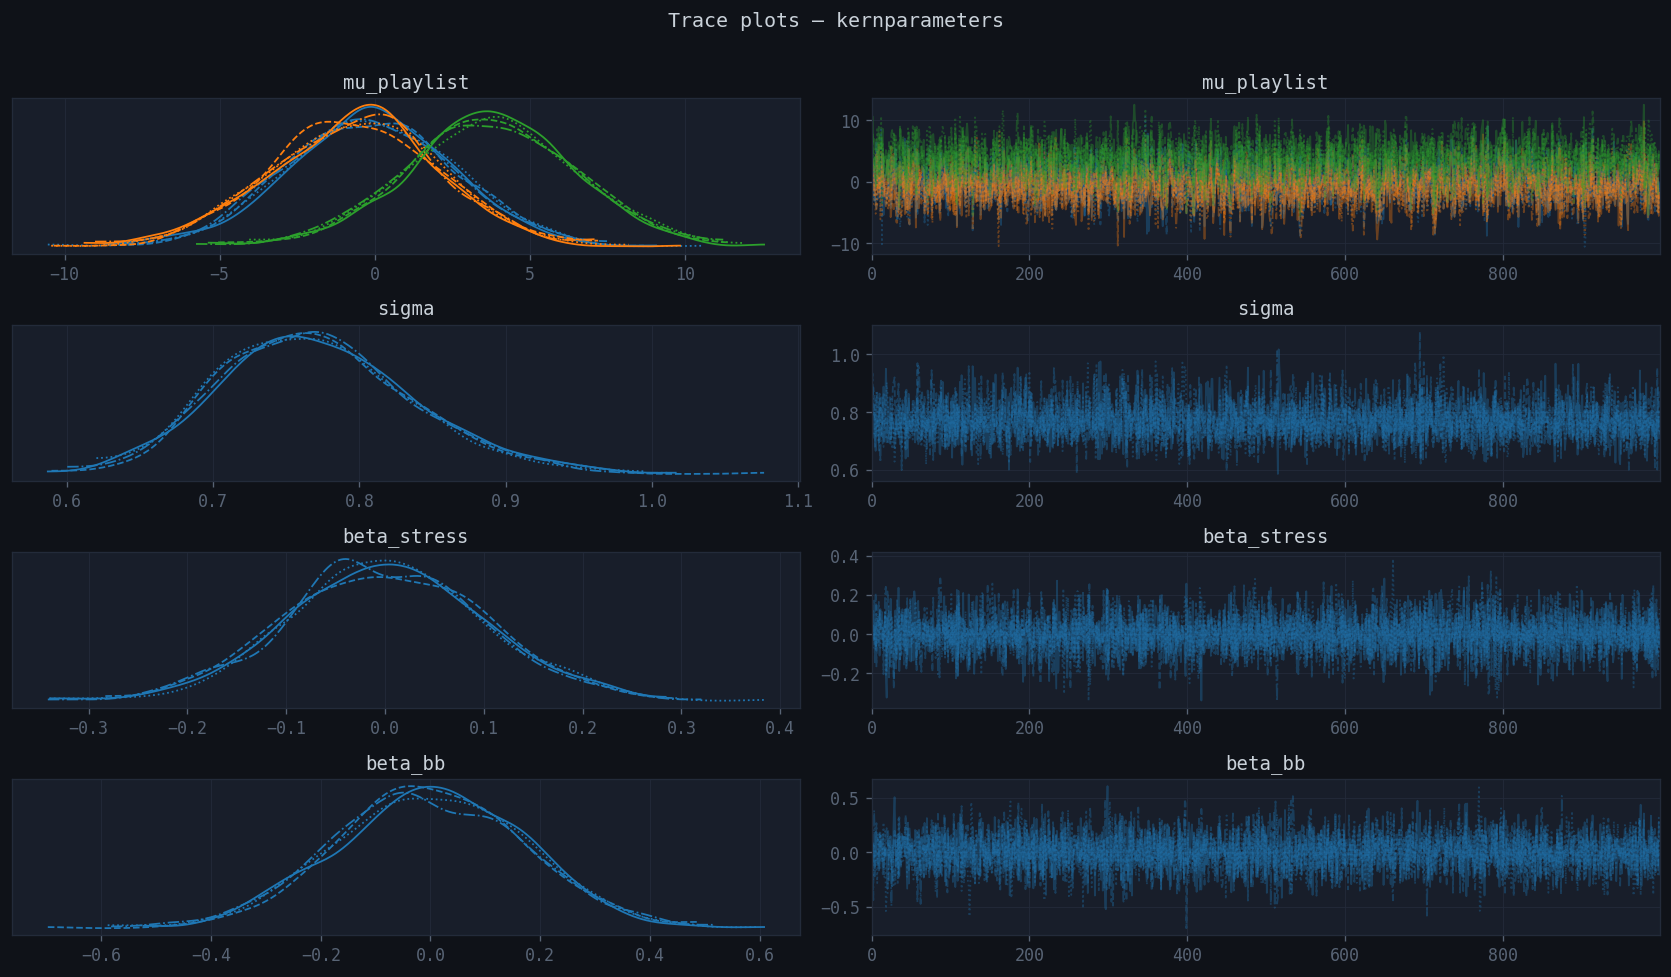

In [9]:
az.plot_trace(
    trace,
    var_names=["mu_playlist", "sigma", "beta_stress", "beta_bb"],
    compact=True, figsize=(14, 8),
)
plt.suptitle("Trace plots \u2014 kernparameters", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(BAYES_OUT / "trace_plots.png", bbox_inches="tight", dpi=150)
plt.show()

---

## 6. Exporteren

In [10]:
param_summary.to_csv(BAYES_OUT / "parameter_summary.csv")
export_streamlit_json(trace, model, MODELS_DIR / "summary.json")

print(f"  -> {BAYES_OUT / 'parameter_summary.csv'}")
print(f"  -> {MODELS_DIR / 'summary.json'}")
print(f"\nModel artifacts : {MODELS_DIR}")
print(f"Analyses        : {BAYES_OUT}")

  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender\summary.json
  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\data\analysis\bayesian_recommender\parameter_summary.csv
  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender\summary.json

Model artifacts : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender
Analyses        : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\data\analysis\bayesian_recommender
